Authors:
- Student 1 : Piu, Maurizio
- Student 2 : Tauss, Joël

# MPW2 - Computational graphs

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

# added imports
import os
from numpy import ndarray

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0
cg.backward()
print(x1.grad_v, x2.grad_v, f.grad_v)

f = 64.0
64.0 32.0 1.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
# datafile = "../data/lausanne-appart.csv"
datafile = os.path.join("data", "lausanne-appart.csv")
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
dataset.describe()

,living_area,nb_rooms,rent_price
count,231.000000,231.000000,231.000000
mean,98.497835,3.484848,2594.272727
std,60.244421,1.699357,1270.325507
min,13.000000,1.000000,685.000000
25%,51.000000,2.000000,1635.000000
50%,90.000000,3.500000,2380.000000
75%,127.000000,4.500000,3385.000000
max,275.000000,8.000000,6150.000000


In [5]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [6]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend,
# also optional.
def plot_data_prediction(
    x_points,
    y_points,
    x_curve=None,
    y_curve=None,
    x_title="x",
    y_title="y",
    theta_0=None,
    theta_1=None,
    theta_2=None,
):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)  # ex "Living area (m^2)"
    plt.ylabel(y_title)  # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = rf"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += rf", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

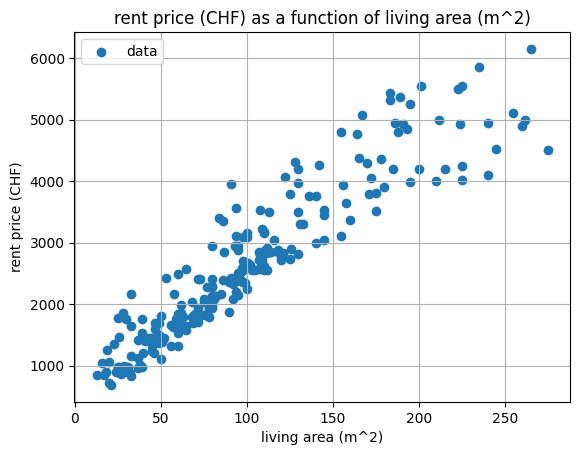

In [7]:
plot_data_prediction(
    living_area, rent_price, x_title="living area (m^2)", y_title="rent price (CHF)"
)

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150315
slope (theta_1)    : 19.661179947454315


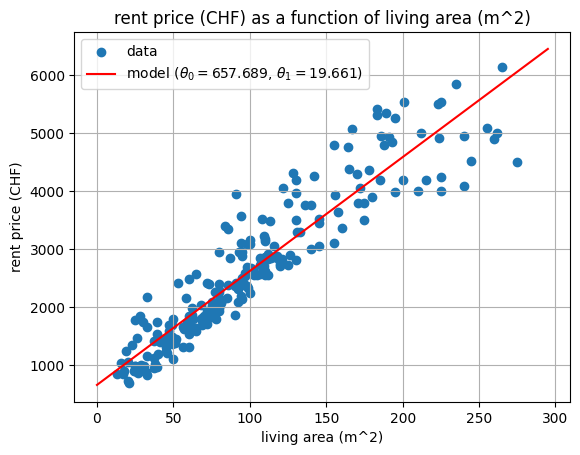

In [8]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta: ndarray = inv(np.array(X.T @ X)) @ X.T @ y  # TO COMPLETE --> 2d array

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title="living area (m^2)",
    y_title="rent price (CHF)",
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

> Note Maurizio:<br>
Interesting observation: for living area of zero m2, the (predicted) price is still around 660 CHF - this is an interesting mismatch between model prediction and actual real world situation. Of course in reality there is just a "cutoff" for the smallest amount of m2 with some price for it - but this type of model is not able to represent this mismatch.

b) Compute the overall MSE loss :


>Note Joël:<br>
The formula for reference:
\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}


In [9]:
def mse_loss(y_hat, y) -> float:
    """Returns the mean squared error loss"""

    n: int = len(y)
    mse: float = 1 / (2 * n) * np.sum((y_hat - y) ** 2)
    return mse


y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913583


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

> Note Joël: Implemented the following formulas accordingly<br><br>
RMSE Formula 
\begin{equation*}
	RMSE = \sqrt{\frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}}
\end{equation*}
MAE Formula
\begin{equation*}
MAE = \frac{1}{N} \sum_{n=1}^{N} \left| \hat{y}_{n} - y_{n} \right|
\end{equation*}
MAPE
\begin{equation*}
MAPE = \frac{100}{N} \sum_{n=1}^{N} \left| \frac{\hat{y}_{n} - y_{n}}{y_{n}} \right|
\end{equation*}






In [10]:
def rmse_loss(y_hat, y) -> float:
    """returns the root mean squared error loss"""
    # mse : float = mse_loss(y_) # to not cause errors later on, we implement it from scratch

    n: int = len(y)
    mse: float = (
        1 / n * np.sum((y_hat - y) ** 2)
    )  # TODO: unsurue, if we should use 1/n or 1/2n?
    rmse: float = np.sqrt(mse)
    return rmse


def mae_loss(y_hat, y) -> float:
    """returns the mean absolute error"""

    n: int = len(y)
    mae: float = np.mean(
        np.abs(y - y_hat)
    )  # alt: mae = 1 / n * np.sum(np.abs(y - y_hat))
    return mae


def mape_loss(y_hat, y) -> float:
    """returns the mean absolute percentage error as (NOT multiplied by 100)"""

    n: int = len(y)
    mape: float = np.mean(
        np.abs((y_hat - y) / y)
    )  # alt: mape = 100 / n * np.sum(np.abs((y_hat - y) / y))
    return mape


mse = mse_loss(y_hat, y)
rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the MSE loss is:\t", round(mse))
print("The total value of the RMSE loss is:\t", round(rmse))
print("The total value of the MAE loss is:\t", round(mae))
print("The total value of the MAPE loss is:\t", f"{mape_percent:.1f}%")

The total value of the MSE loss is:	 104915
The total value of the RMSE loss is:	 458
The total value of the MAE loss is:	 347
The total value of the MAPE loss is:	 14.6%


> Notes on Errors:
- For all except the MAPE, the unit would be USD, since it is the target value y. This does not make sense to consider for the MSE.
- For human interpretation the MAPE is the easiest to understand out of the bunch, when just looking at these numbers. For the other errors to make sense, one needs to know the output value range and unit to better judge the result.
- MSE loss: The squared error is quite high, because it punishes greater single deviations harder, due to the error being squared
- RMSE loss: The same applies here. 
- MAE loss: The MAE loss is less susceptible to larger errors, hence it is lower then the RMSE.
- All the errors, when considering y's value range, is quite low. This comes down to the linear nature of the data. So the outcome is not really surprising.

> Extra question: What could be the problem with MAPE ?
- Unlike the MSE and RMSE, the MAPE (and the MAE) do not punish predictions which are far off as harshly as the other two. This comes from the fact, the MAPE does not square the delta between y and y_hat.
- The MAPE could lead to an division by zero error, if not handled correctly in the method implementation. This should not be the case in our example.
- If the value range of y (and thus y_hat) are small, it can result in very high percentage errors.
- The MAPE is not smooth nor differentiable at 0, making it difficult to use in gradient descent optimization

Source: <a href="https://medium.com/@abhishekjainindore24/mape-mean-absolute-percentage-error-and-smape-symmetric-mape-loss-function-for-regression-3461841892de">MAPE — Mean Absolute Percentage Error and SMAPE — Symmetric MAPE — Loss function for regression</a>

TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?
-> Done

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [23]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()
q = ValueNode()
y_hat = ValueNode()
j = ValueNode()  # output

# then create all <Operator>Node objects
mult = MultiplyNode(x, theta_1, q)
plus = AddNode([q, theta_0], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [24]:
# try a forward pass with dummy values

cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [25]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [18]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the
# evolution of theta_0 and theta_1 is used to plot the model curve.


def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle("Training log")
    ax1.plot(t0_evolution)
    ax1.set_title("theta 0")
    ax2.plot(t1_evolution)
    ax2.set_title("theta 1")
    ax3.plot(loss_evolution)
    ax3.set_title("loss")
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = (
        t0_evolution[-1] + t1_evolution[-1] * x_curve
    )  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color="red")
    ax4.set_title("points and model output")
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.004946586268433
slope (theta_1)    : 24.471045083461075
The total value of the loss is 163446.37753720794


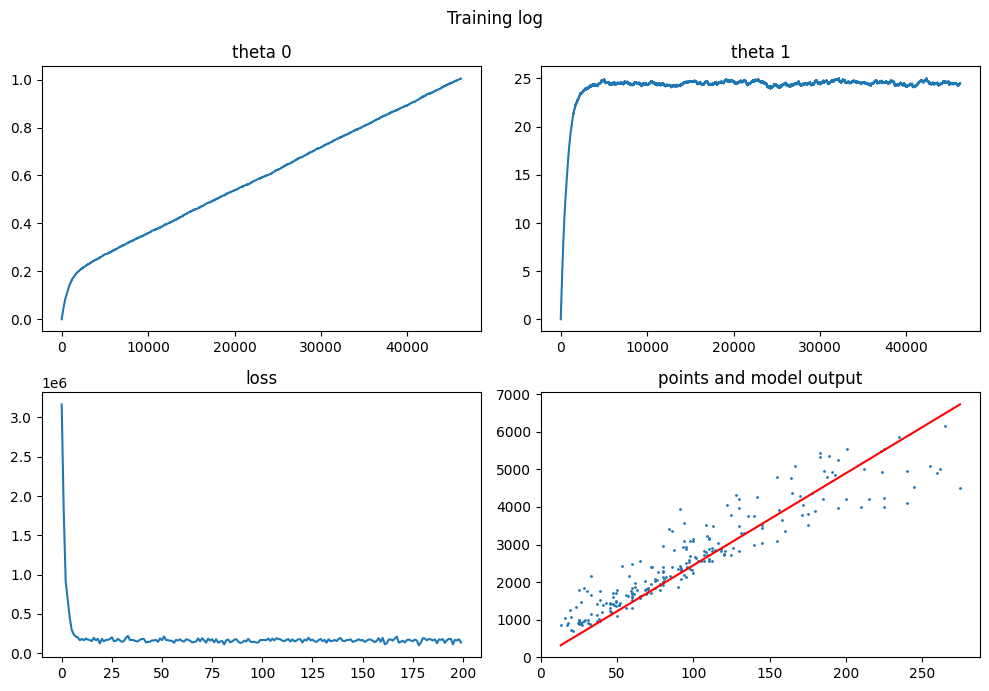

In [26]:
alpha = 0.0000001  # learning rate
epochs = 200  # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0  # initial value of theta_0
t1 = 0.0  # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []  # to log the evolution of theta_0
t1_evolution = []  # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):

        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - theta_0.grad_v * alpha  # TODO: update rule for theta_0 -> Done
        t1 = t1 - theta_1.grad_v * alpha  # TODO: update rule for theta_1 -> Done

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

In [22]:
# Added for comparison)
print(f"Linear regression model\n{45*'-'}")
print("intercept (theta_0)  : ", theta[0])  # should be around 658
print("slope (theta_1)      : ", theta[1])  # should be around 19.7
print("mse linear regression: ", mse)

Linear regression model
---------------------------------------------
intercept (theta_0)  :  657.6890591150315
slope (theta_1)      :  19.661179947454315
mse linear regression:  104915.13056913583


**Your observations:**

- Evolution of the loss:
    - Rapidly decreases to about 0.2 but then stagnates
    - Implies the model is not improving anymore with the given parameters
- Evolution of theta_1:
    - Rapidily increases to about 24 but then stagnates
    - Implies the slope (coefficient) gets to where it should be quite fast. This can also be seen in the output plot.
- Evolution of theta_0:
    - Continuously increases until the last epoch
    - Implies that the intercept is not yet optimized / fitted to the data completely
    - This is most likely due to the low learning alpha rate of 1e-7
- Metric comparison to linear regression:
    - The intercept (theta 0) is much lower on the cg model at around 1, compared to the 658 of the linear regression. This strengthens the argument from before, that theta 0 is not yet fitted to the data
    - The slope (theta 1) is higher on the cg model at 24, compared to the 20 of the linear regression. We think, this is to compensate for the much lower intercept (theta 0), caused by the small alpha.
    - The MSE loss of the cg model is thus much higher (which is not surpsrising), becuase of the before mentioned factor.

### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

> Note:<br>
> There are two ways to do mini batch gradient descent: sequential and random.<br>
> We implemented both, but this behaviour can be changed with the defined mentioned parameter

In [27]:
# True: uses random sampling to fetch samples in a batch
# False: uses sequential batches and uses all available training data
random_sampling: bool = False

intercept (theta_0): 0.5244353393378888
slope (theta_1)    : 22.690135544858517
The total value of the loss is 185867.66430443956


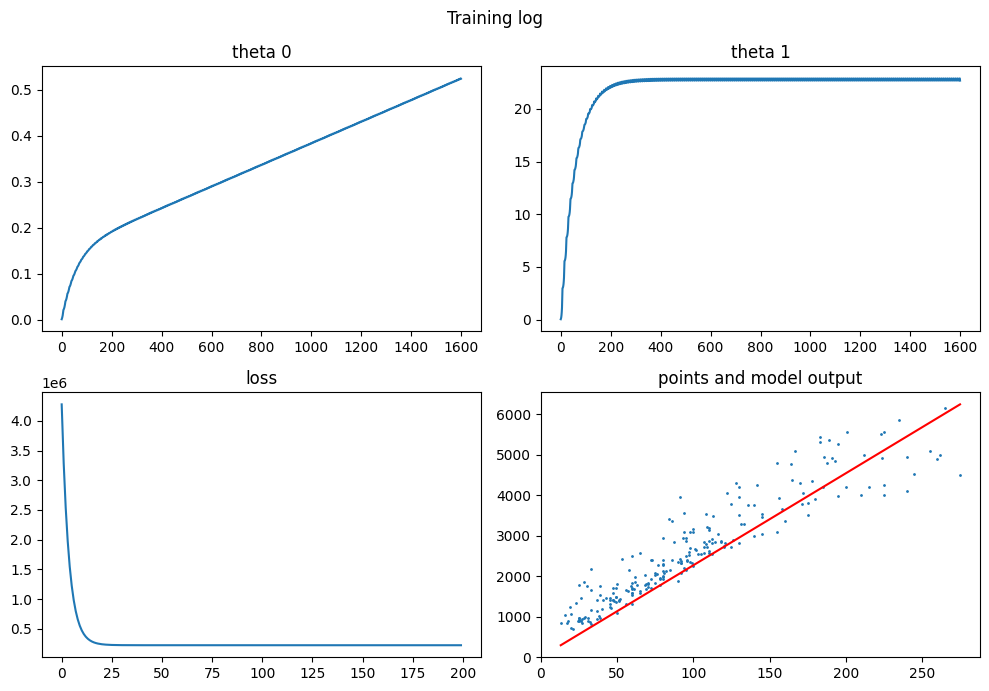

In [28]:
# TODO:
# compute the gradients and update theta_0 and theta_1 with the average
# of the gradients over the batch

alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []


for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0

    for step in range(n_steps):

        # random sampling
        if random_sampling:
            batch_indexes: list = random.sample(range(N), batch_size)

        # sequential sampling
        else:
            end: int = (step + 1) * batch_size
            if (step + 1) == n_steps:
                end: list = N
            batch_indexes: list = range(step * batch_size, end)

        # we will average the loss as well, i am not sure if this is correct
        theta_0_values: list = []
        theta_1_values: list = []
        loss_values: list = []

        # get values from batch
        for i in batch_indexes:

            cg.reset_values()
            cg.forward([living_area[i], t0, t1, rent_price[i]])
            cg.backward()

            theta_0_values.append(theta_0.grad_v)  # gradient theta_0
            theta_1_values.append(theta_1.grad_v)  # gradient theta_1
            loss_values.append(j.v)

        # get mean values per batch
        t0 -= alpha * np.mean(theta_0_values)
        t1 -= alpha * np.mean(theta_1_values)
        epoch_loss += np.mean(loss_values)

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)


# generate output
print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** - COMPLETED

- Evolution of theta_0 and theta_1:
    - theta_0 still seems to only increase without any sign of convergence (...might need optimizers as we will see in next step)
    - theta_1 converges relatively quickly to its final value
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ?
    - In terms of the values approached, both thetas show the same behaviour as with plain stochastic.
    - The biggest change is visible in value stability and decreased noise (particularly with theta_1)
- Can we use larger learning rates than in the plain stochastic version ?
    - Yes, as we average the losses over the batch, we can apply higher lr value in training.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

> Note:<br>
> It was not specified to use SGD or mini batch GD<br>
> We opted to use mini batch GD with a smaller batch size of 4

intercept (theta_0): 631.4237596659699
slope (theta_1)    : 19.77126596467146
The total value of the loss is 105055.94757504207


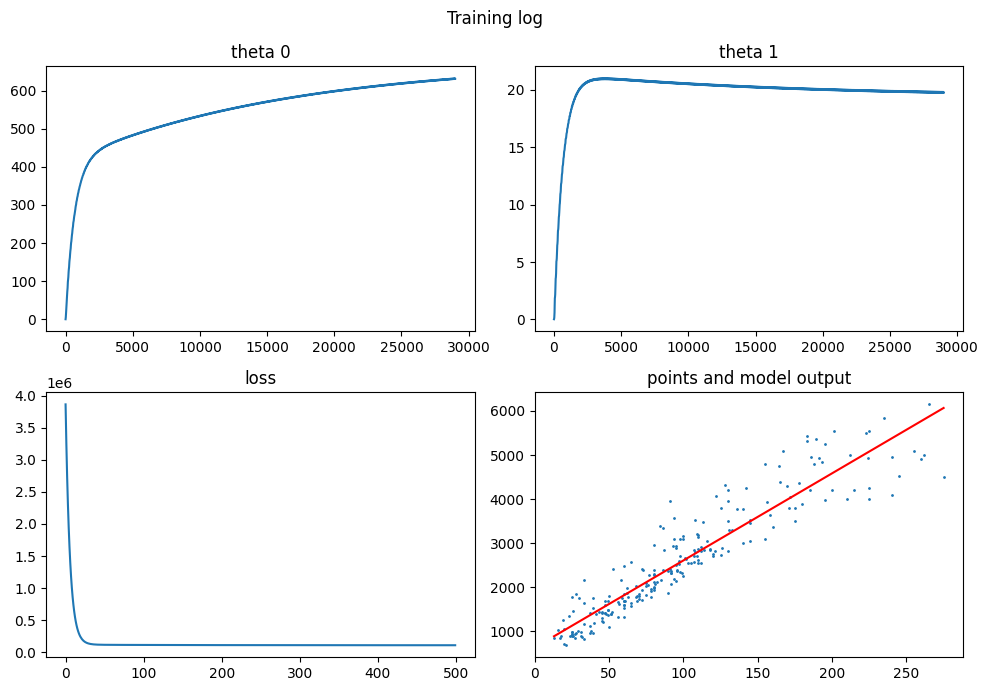

In [29]:
alpha_t0 = 0.00025  # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500  # number of epochs (an epoch is a loop over the whole training set)

batch_size = 4  # small batch size for faster convergence
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []


for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0

    for step in range(n_steps):

        # random sampling
        if random_sampling:
            batch_indexes: list = random.sample(range(N), batch_size)

        # sequential sampling
        else:
            end: int = (step + 1) * batch_size
            if (step + 1) == n_steps:
                end: list = N
            batch_indexes: list = range(step * batch_size, end)

        # we will average the loss as well, i am not sure if this is correct
        theta_0_values: list = []
        theta_1_values: list = []
        loss_values: list = []

        # get values from batch
        for i in batch_indexes:

            cg.reset_values()
            cg.forward([living_area[i], t0, t1, rent_price[i]])
            cg.backward()

            theta_0_values.append(theta_0.grad_v)  # gradient theta_0
            theta_1_values.append(theta_1.grad_v)  # gradient theta_1
            loss_values.append(j.v)

        # get mean values per batch
        t0 -= alpha_t0 * np.mean(theta_0_values)  # small change to alpha
        t1 -= alpha_t1 * np.mean(theta_1_values)  # small change to alpha
        epoch_loss += np.mean(loss_values)

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)


# generate output
print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

In [31]:
# Added for comparison)
print(f"Linear regression model\n{45*'-'}")
print("intercept (theta_0)  : ", theta[0])  # should be around 658
print("slope (theta_1)      : ", theta[1])  # should be around 19.7
print("mse linear regression: ", mse)

Linear regression model
---------------------------------------------
intercept (theta_0)  :  657.6890591150315
slope (theta_1)      :  19.661179947454315
mse linear regression:  104915.13056913583


**Your observations**
- With the change in learning rate for the theta_0 (the intercept), the parameter was able to converge to a value (631)
- theta_0 is now much closer to the value, calculated from the linear regression
- The total loss has decreased significantly to 105'226 (previously 105'055 with mini-batch)
- The change in learning rate had the desired effect of improving the cg model

### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 679.1510791532446
slope (theta_1)    : 19.43523175219564
The total value of the loss is 105007.68912109989


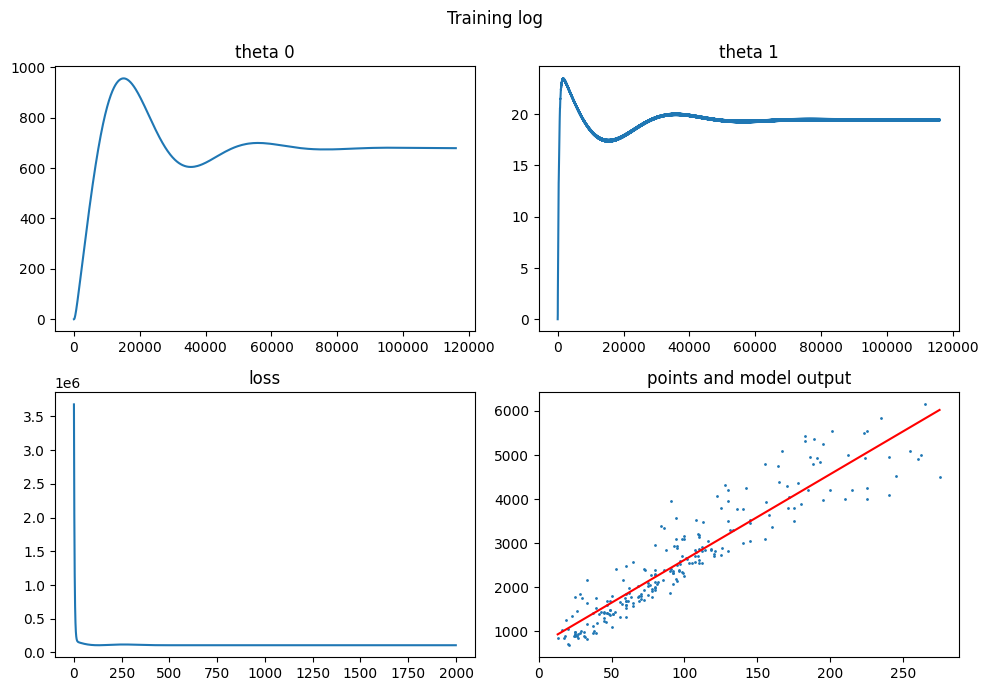

In [36]:
alpha = 0.0000001  # learning rate

beta_momentum_t0 = 0.9999  # momentum factor for theta_0
beta_momentum_t1 = 0.5000  # momentum factor for theta_1
epochs = 2000  # number of epochs (an epoch is a loop over the whole training set)


batch_size = 4  # small batch size for faster convergence
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

# added to track the previous momentum, init with 0 as there is no initial momentum
m_t0: float = 0
m_t1: float = 0

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0

    for step in range(n_steps):

        # random sampling
        if random_sampling:
            batch_indexes: list = random.sample(range(N), batch_size)

        # sequential sampling
        else:
            end: int = (step + 1) * batch_size
            if (step + 1) == n_steps:
                end: list = N
            batch_indexes: list = range(step * batch_size, end)

        # we will average the loss as well, i am not sure if this is correct
        theta_0_values: list = []
        theta_1_values: list = []
        loss_values: list = []

        # get values from batch
        for i in batch_indexes:

            cg.reset_values()
            cg.forward([living_area[i], t0, t1, rent_price[i]])
            cg.backward()

            theta_0_values.append(theta_0.grad_v)  # gradient theta_0
            theta_1_values.append(theta_1.grad_v)  # gradient theta_1
            loss_values.append(j.v)

        # calculate the momentum and update the thetas
        m_t0 = beta_momentum_t0 * m_t0 + alpha * np.mean(theta_0_values)
        m_t1 = beta_momentum_t1 * m_t1 + alpha * np.mean(theta_1_values)

        t0 -= m_t0
        t1 -= m_t1

        epoch_loss += np.mean(loss_values)

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)


# generate output
print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**:
- The momentum can be clearly seen in the evolution of the thetas 0 and 1
- The loss is slightly higher than on the previous version with separate learning rates for each theta
- More epochs would be needed to further converge the cg model (written with epochs=400)
    - Experimenting with different amount of epochs leads to observation that theta_0 starts to stabilise/converge at around epoch 1200 and seem to achieve full convergence by epoch 1800. The other parameter theta_1 stabilises earlier at around epoch 1000.


## Optional objectives (Overview)

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


## 6. 2nd Order Model (Optional) 

Task: "Investigate the use of 2nd order model instead of the simple linear model."

Second order polynomial regression model:
\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x + \theta_{2} x^2
\end{equation*}

Here is a visualisation of the computational graph that this leads to:

![](images/compgraph_2nd_order.drawio.png)

In [38]:
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
theta_2 = ValueNode()
x = ValueNode()
xsq = ValueNode() # x squared intermediary node
y = ValueNode()
p = ValueNode()
q = ValueNode()
r = ValueNode()
y_hat = ValueNode()
j = ValueNode()  # output

# then create all <Operator>Node objects
mult_sq = MultiplyNode(x, x, xsq)
mult_p = MultiplyNode(xsq, theta_2, p)
mult_q = MultiplyNode(x, theta_1, q)
plus_r = AddNode([p, q], r)
plus_yhat = AddNode([r, theta_0], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, theta_2, y], [j])

In [39]:
# try a forward pass with dummy values

cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5
